<a href="https://colab.research.google.com/github/thecodingAdi/ai-ml-playground/blob/main/insurance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [68]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [69]:
#import os

#path = r'C:\Users\Hp\Documents\VS code programs\python programme\Jupyter\ai-ml-playground'
#print(os.listdir(path))

#### You can upload files directly to your Colab environment. Here's how you can do it using `google.colab.files.upload()`:
#### The below cell is used in colab decomment to use in colab

In [70]:
#from google.colab import files
#
#uploaded = files.upload()
#
#for fn in uploaded.keys():
#  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')



#### The below cell is used in editors
#### After uploading the `insurance.csv` file, you can then read it using `pd.read_csv('insurance.csv')`.

In [120]:
df = pd.read_csv('insurance.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [121]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [122]:
df.shape

(1338, 7)

In [123]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [124]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [125]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [126]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

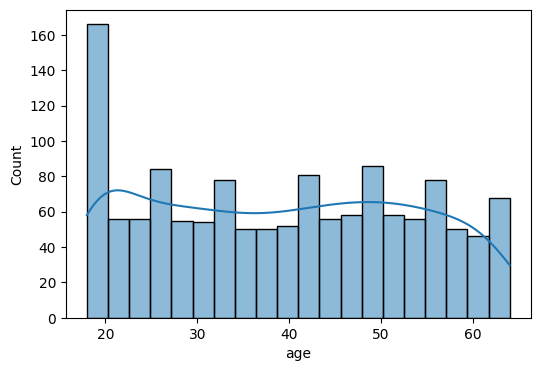

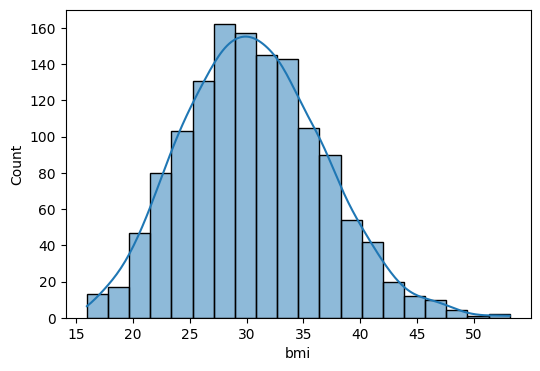

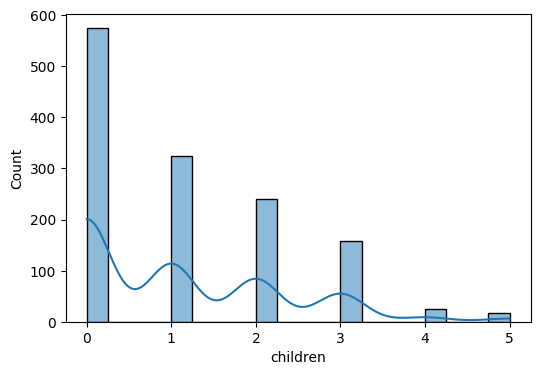

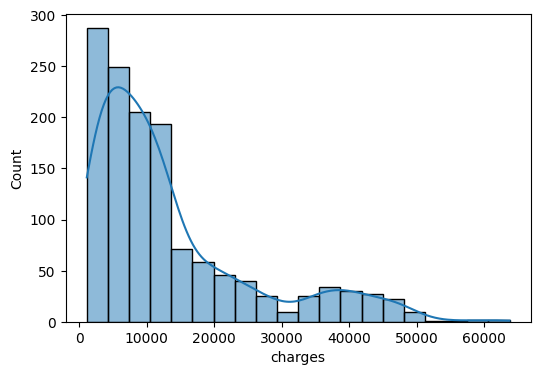

In [127]:
numeric_columns = ['age', 'bmi', 'children','charges']
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde = True,bins = 20)

<Axes: xlabel='children', ylabel='count'>

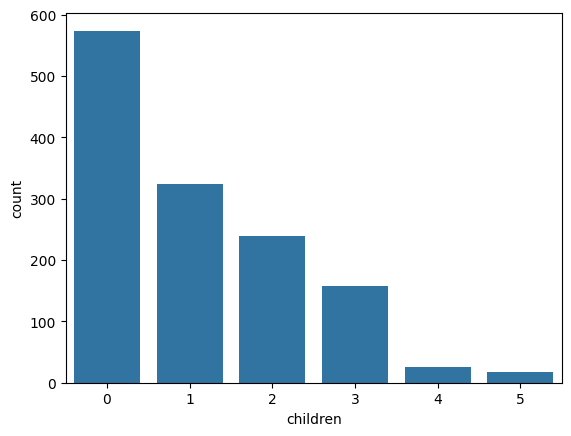

In [128]:
sns.countplot(x = df['children'])

<Axes: xlabel='sex', ylabel='count'>

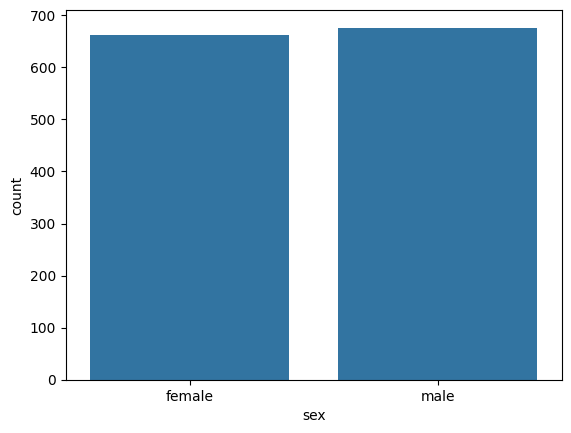

In [129]:
sns.countplot(x = df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

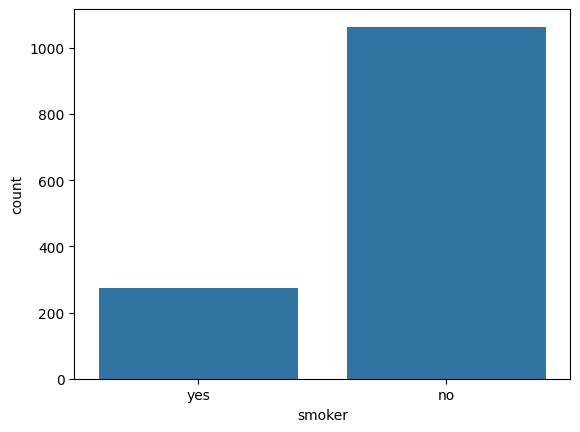

In [130]:
sns.countplot(x = df['smoker'])

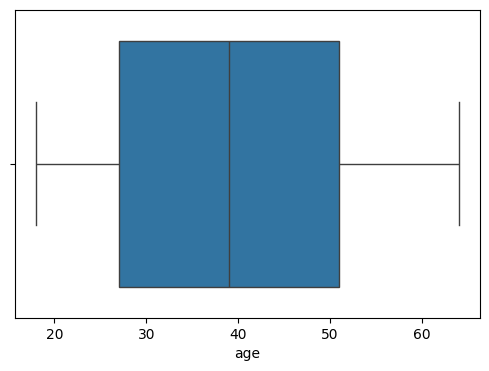

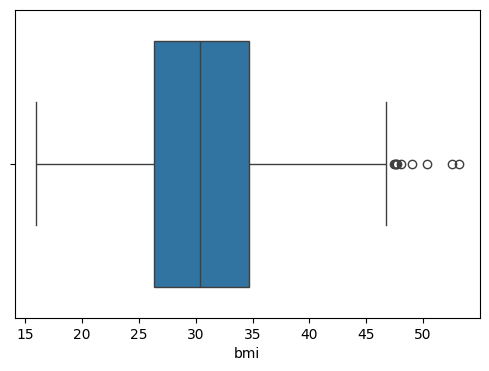

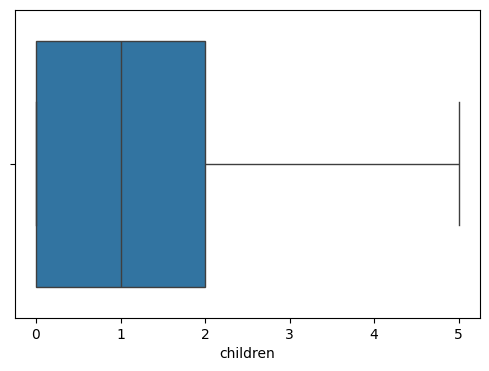

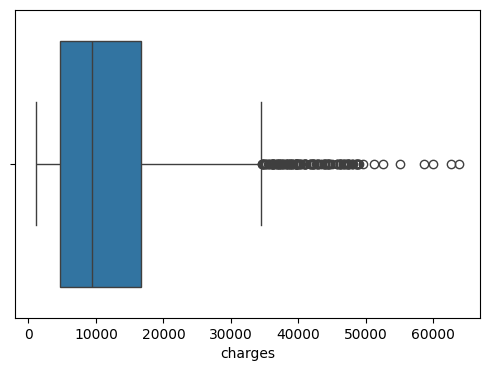

In [131]:
for col in numeric_columns:
    plt.figure(figsize= (6,4))
    sns.boxplot(x = df[col])

<Axes: >

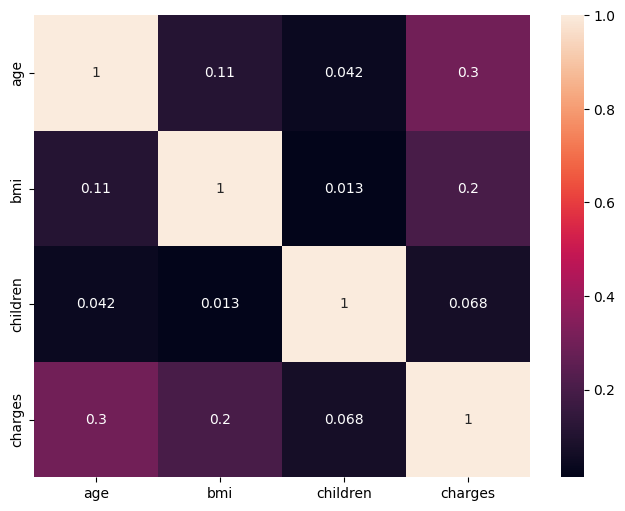

In [132]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

## Data Cleaning and preprocessing

In [84]:
df_cleaned = df.copy()

In [85]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [86]:
df_cleaned.shape

(1338, 7)

In [87]:
df_cleaned.drop_duplicates(inplace=True)

In [88]:
df_cleaned.shape

(1337, 7)

In [89]:
df_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [90]:
df_cleaned.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [91]:
df_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [92]:
df_cleaned['sex'] = df_cleaned['sex'].map({ "male" :0, "female" : 1})

In [93]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [94]:
df_cleaned['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [95]:
df_cleaned['smoker'] = df_cleaned['smoker'].map({"no" : 0,"yes" : 1})
df_cleaned

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830
1334,18,1,31.920,0,0,northeast,2205.98080
1335,18,1,36.850,0,0,southeast,1629.83350
1336,21,1,25.800,0,0,southwest,2007.94500


In [96]:
df_cleaned.rename(columns={
    'sex' :'is_female',
    'smoker': 'is_smoker'},inplace = True)

df_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [97]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [98]:
df_cleaned = pd.get_dummies(df_cleaned,columns = ['region'],drop_first=True)

In [99]:
df_cleaned = df_cleaned.astype(int)
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0
1334,18,1,31,0,0,2205,0,0,0
1335,18,1,36,0,0,1629,0,1,0
1336,21,1,25,0,0,2007,0,0,1


In [100]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0


In [101]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='str')

In [102]:
from sklearn.preprocessing import StandardScaler
cols = ['age','bmi','children']
scaler = StandardScaler()

df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])

In [103]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0


In [104]:
from scipy.stats import pearsonr

# ----------------------------------
# Pearson Correlation Calculation
# ----------------------------------

# List of features to check against target
selected_features = [
    'age', 'bmi', 'children', 'is_female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest'
]

correlations = {
    feature: pearsonr(df_cleaned[feature], df_cleaned['charges'])[0]
    for feature in selected_features
}
correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])
correlation_df.sort_values(by='Pearson Correlation', ascending=False)

,Feature,Pearson Correlation
4,is_smoker,0.787234
0,age,0.298309
1,bmi,0.196236
6,region_southeast,0.073577
2,children,0.067390
5,region_northwest,-0.038695
7,region_southwest,-0.043637
3,is_female,-0.058046


In [105]:
cat_features = [
    'is_female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'
]

In [106]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'], q=4, labels=False)
chi2_results = {}

for col in cat_features:
    if col not in df_cleaned.columns:
        print(f"Skipping '{col}' as it is not found in df_cleaned columns.")
        continue
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df

Skipping 'bmi_category_Normal' as it is not found in df_cleaned columns.
Skipping 'bmi_category_Overweight' as it is not found in df_cleaned columns.
Skipping 'bmi_category_Obese' as it is not found in df_cleaned columns.


,chi2_statistic,p_value,Decision
is_smoker,848.219178,0.0,Reject Null (Keep Feature)
region_southeast,15.998167,0.001135,Reject Null (Keep Feature)
is_female,10.258784,0.01649,Reject Null (Keep Feature)
region_southwest,5.091893,0.165191,Accept Null (Drop Feature)
region_northwest,1.13424,0.768815,Accept Null (Drop Feature)


In [107]:
final_df = df_cleaned[['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges','region_southeast']]

In [108]:
final_df

,age,is_female,bmi,children,is_smoker,charges,region_southeast
0,-1.440418,1,-0.517949,-0.909234,1,16884,0
1,-1.511647,0,0.462463,-0.079442,0,1725,1
2,-0.799350,0,0.462463,1.580143,0,4449,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,0
...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,0
1334,-1.511647,1,0.135659,-0.909234,0,2205,0
1335,-1.511647,1,0.952670,-0.909234,0,1629,1
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0


In [109]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


Creating model from above Data

In [110]:
from sklearn.model_selection import train_test_split

In [111]:
x = final_df.drop(columns=['charges'])
y = final_df['charges']

In [112]:
X_train , X_test , Y_train , Y_test = train_test_split(x,y,test_size=0.2,random_state = 42)

In [113]:
from sklearn.linear_model import LinearRegression

In [114]:
model = LinearRegression()
model.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [115]:
Y_pred = model.predict(X_test)


In [116]:
from sklearn.metrics import r2_score

r2= r2_score(Y_test,Y_pred)
r2

0.8053741941169438

In [117]:
n = X_test.shape[0]
p = X_test.shape[1]


adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

adjusted_r2

0.8009000376598621

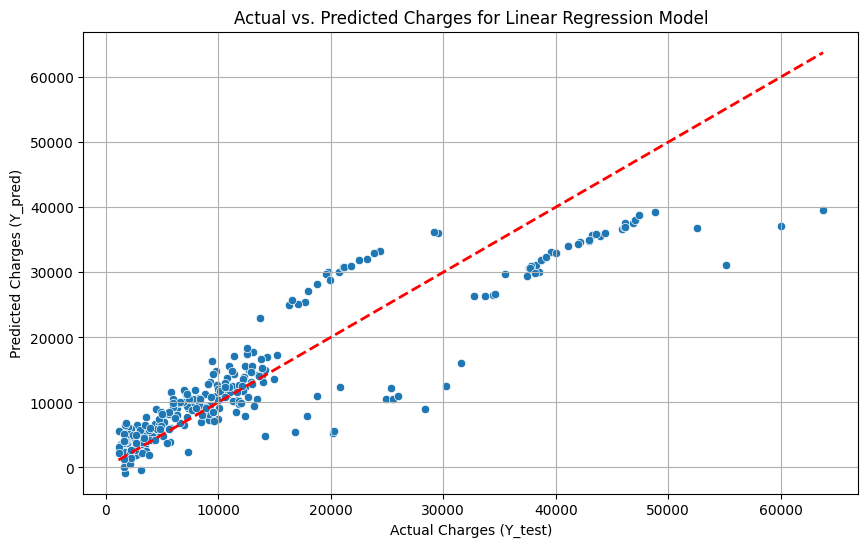

In [118]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=Y_test, y=Y_pred)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Charges (Y_test)")
plt.ylabel("Predicted Charges (Y_pred)")
plt.title("Actual vs. Predicted Charges for Linear Regression Model")
plt.grid(True)
plt.show()

In [119]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Mean Absolute Error (MAE): 4185.22
Mean Squared Error (MSE): 35763676.15
Root Mean Squared Error (RMSE): 5980.27


### Interpretation of the Metrics:
*   **Mean Absolute Error (MAE):** This is the average of the absolute differences between predictions and actual observations. It measures the average magnitude of the errors in a set of predictions, without considering their direction. A lower MAE indicates a better fit.
*   **Mean Squared Error (MSE):** This is the average of the squares of the errors. It is useful because it penalizes larger errors more heavily. A lower MSE indicates a better fit.
*   **Root Mean Squared Error (RMSE):** This is the square root of the MSE. It is often preferred in some applications because it is in the same units as the target variable (charges, in this case), making it more interpretable than MSE. A lower RMSE indicates a better fit.

### Testing the Model with Custom Input

To get a prediction from your trained `LinearRegression` model with new input, follow these steps:

1.  **Prepare your input data:** Create a Pandas DataFrame with a single row (or multiple rows for multiple predictions). The column names must match the features `x` (i.e., `age`, `is_female`, `bmi`, `children`, `is_smoker`, `region_southeast`).
2.  **Apply the same preprocessing:** If you scaled certain features during training (like `age`, `bmi`, `children`), you must apply the *same* `StandardScaler` to your new input data for those features.
3.  **Make a prediction:** Use the `model.predict()` method on your preprocessed input DataFrame.